In [1]:
import numpy as np
from matplotlib import pyplot as plt
from dataholder import DataHolderXYZ, DataHolderXY

## dhxy (1D data) example

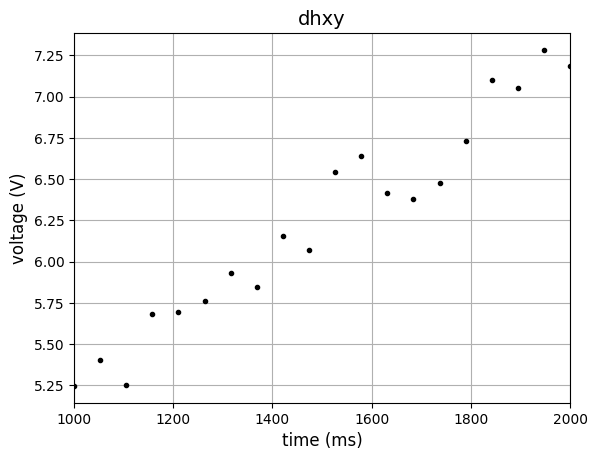

In [2]:
## create dhxy object
# example data
x = np.linspace(1, 2, 20)
y = 2*x + 3 + np.random.random(20)/2 # y = 2x + 3 + noise

# define dhxy object and set values, names and units
dhxy = DataHolderXY()
dhxy.set_data_name_unit('x', x, 'time', 's')
dhxy.set_data_name_unit('y', y, 'voltage', 'V')
dhxy.plot('k .', xunit='ms') # can set unit for plotting

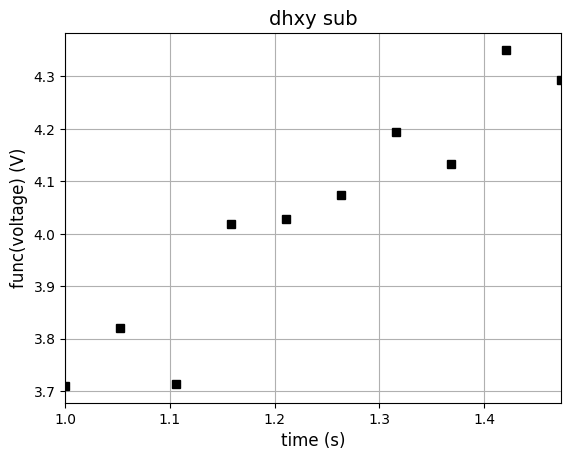

In [3]:
## cut a portion of it, can also apply function to data
dhxy_cutted = dhxy.get_sub_dhxy(xlim=[1, 1.5], yfunc=lambda x: x/np.sqrt(2))
dhxy_cutted.plot('k s')

fitted result:
>> a = 1.33905e+00
>> b = 2.37739e+00
with R-squared value R^2 = 0.89414


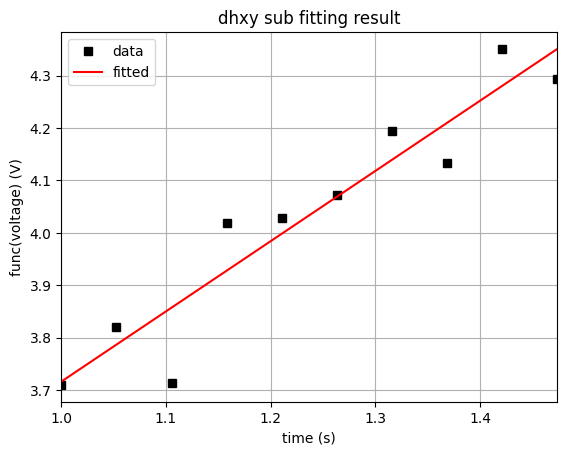

In [4]:
## linear fit and exp decay fit are written, can use general_fit for other cases. 
coeffs, Rsquared = dhxy_cutted.linear_fit(print_result=True)

## dhxyz (2D data) example

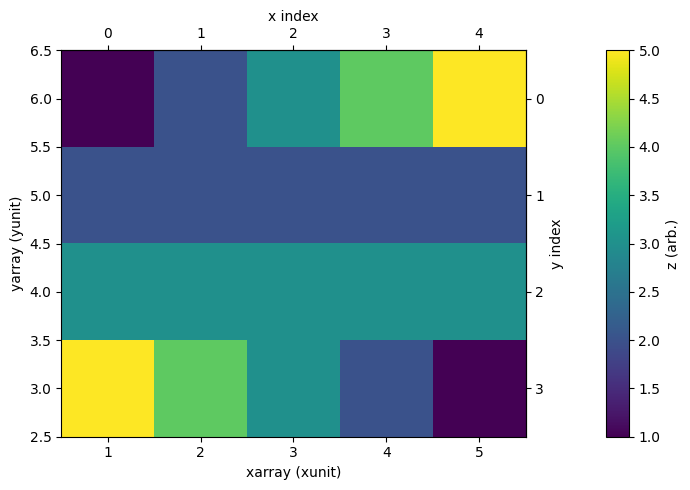

In [5]:
## create dhxyz object
# example data
z = np.array([
    [1, 2, 3, 4, 5,],
    [2, 2, 2, 2, 2,],
    [3, 3, 3, 3, 3,],
    [5, 4, 3, 2, 1,],
])
x = np.array([1, 2, 3, 4, 5])
y = np.array([6, 5, 4, 3])

# create dhxyz object and set data into it
dhxyz = DataHolderXYZ()
dhxyz.set_data_name_unit('x', x, 'xarray', 'xunit') 
dhxyz.set_data_name_unit('y', y, 'yarray', 'yunit')
dhxyz.set_data_name_unit('z', z)
dhxyz.plot()

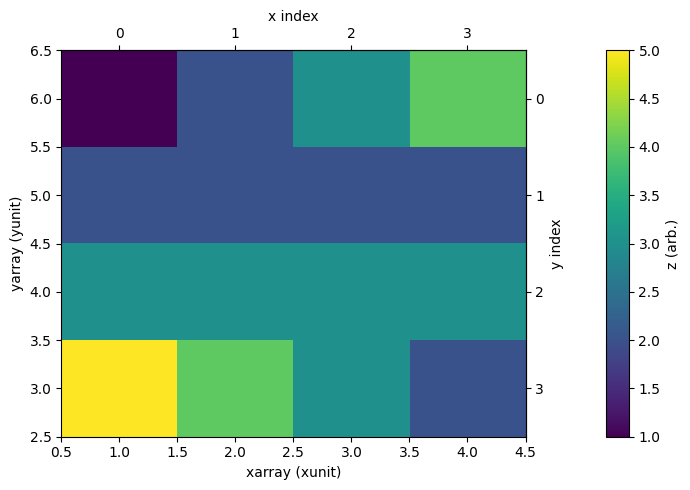

In [6]:
## cut a portion of it
dh_sub = dhxyz.get_sub_dhxyz(xindlim=[0, 3])
dh_sub.plot()

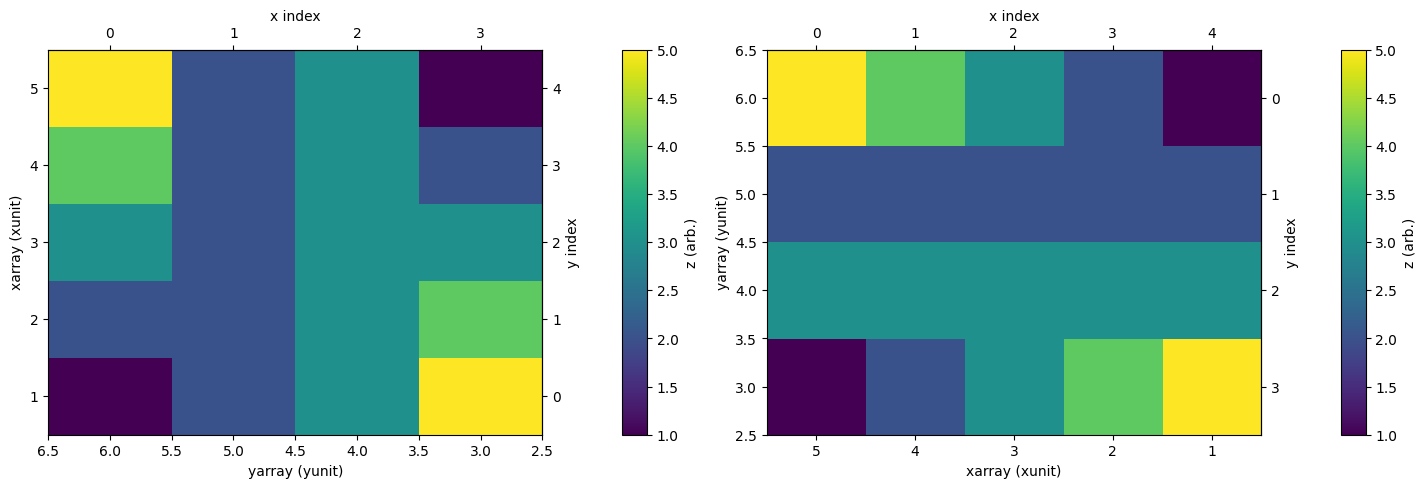

In [7]:
## swap axis or flip it
fig, ax = plt.subplots(1, 2, figsize = (17, 5))

# swap x and y axis
dh_swapxy = dhxyz.get_sub_dhxyz() # copy
dh_swapxy.swap_xy()
dh_swapxy.plot(ax=ax[0])

# flip x axis
dh_xflip = dhxyz.get_sub_dhxyz() # copy
dh_xflip.flip_x()
dh_xflip.plot(ax=ax[1])
plt.show()

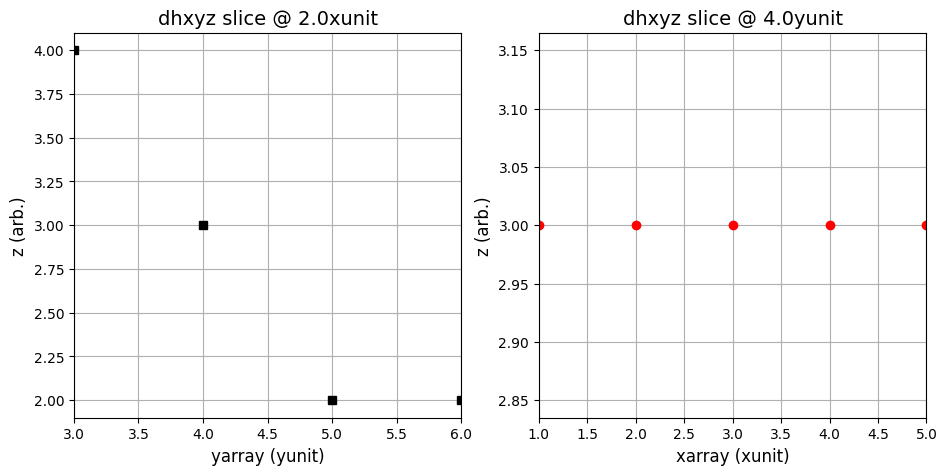

In [8]:
## slice a 1D data out
fig, ax = plt.subplots(1, 2, figsize = (11, 5))

# slice thourgh x
dh_cutted = dhxyz.get_sliced_dhxy('x', slice_index=1)
dh_cutted.plot('k s', ax=ax[0])

# slice through y
dh_cutted = dhxyz.get_sliced_dhxy('y', slice_index=2)
dh_cutted.plot('r o', ax=ax[1])
plt.show()

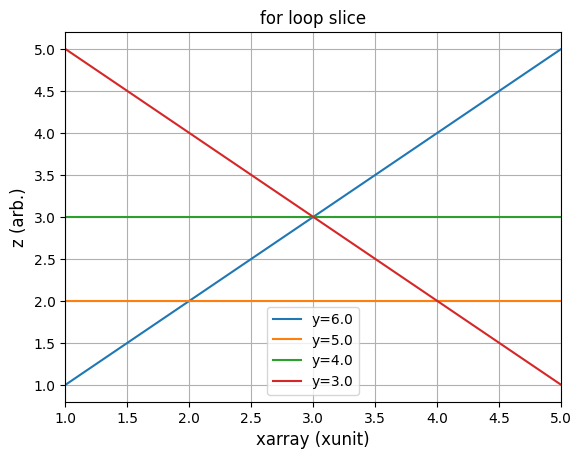

In [9]:
## loop trough 2D data
fig, ax = plt.subplots(1, 1)
for yval, y_dh in dhxyz.sliced_val_and_dhxy('y'):
    y_dh.plot(ax=ax, label=f'y={yval}')
plt.title('for loop slice')
plt.legend()
plt.show()